# Systeme de triage medical aux urgences

Ce notebook met en oeuvre une **chaine de prediction hierarchique** en deux etapes pour
assister le triage des patients aux urgences selon le score ESI (Emergency Severity Index,
1 = critique, 5 = non urgent).

**Architecture :**

```
Donnees patient (age, sexe, lieu, texte clinique)
        |
        v
   Etape 1 : Domaine medical  (4 specialites)
        |  + probabilites domaine
        v
   Etape 2 : Score ESI        (niveaux 1 a 5)
```

**Algorithmes compares a chaque etape :**

| Algorithme | Type | Justification |
|---|---|---|
| Regression Logistique | Lineaire | Modele de reference clinique (Porto, 2024) |
| Random Forest | Ensemble | Robustesse, 2e modele le plus utilise en triage |
| XGBoost | Gradient boosting | Meilleures performances dans la litterature |
| DNN | Reseau de neurones | Capture les relations non lineaires complexes |

**Reference :** Porto et al. (2024). *Systematic review of ML for triage*, BMC Emergency Medicine.
DOI : https://doi.org/10.1186/s12873-024-01135-2


## 1. Installation des dependances

A executer une seule fois si les bibliotheques ne sont pas deja installees.

In [ ]:
# Installation des dependances (a executer une seule fois)
# !pip install pandas numpy scikit-learn xgboost tensorflow openpyxl seaborn matplotlib joblib scipy


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Importation des bibliotheques

Toutes les dependances sont declarees ici en debut de notebook pour faciliter la maintenance
et reperer rapidement les imports manquants.

In [1]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn : preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-learn : modeles
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn : evaluation
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score,
    confusion_matrix, roc_auc_score
)

# XGBoost
from xgboost import XGBClassifier

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Reproductibilite
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow {tf.__version__} | Scikit-learn pret | Environnement configure")

TensorFlow 2.21.0 | Scikit-learn pret | Environnement configure


## 3. Chargement et exploration du jeu de donnees

Le dataset contient des dossiers patients issus des urgences de plusieurs provinces
du Burkina Faso. Chaque dossier comprend un motif de consultation (subject), un
examen clinique (object), des informations demographiques et les labels cibles.

In [8]:
# Chemin vers le dataset
DATA_PATH = '../data/dataset_v4_triage_urgence.xlsx'

df = pd.read_excel(DATA_PATH)
df.columns = df.columns.str.strip()

print(f"Dataset charge : {df.shape[0]} patients x {df.shape[1]} colonnes")
print(f"Colonnes : {df.columns.tolist()}")
print(f"\nValeurs manquantes :")
print(df.isnull().sum())
df.head(3)

Dataset charge : 22392 patients x 7 colonnes
Colonnes : ['age', 'sexe', 'subject', 'object', 'ESI', 'Domaine', 'lieu']

Valeurs manquantes :
age         0
sexe        0
subject     0
object      0
ESI         0
Domaine     0
lieu       33
dtype: int64


,age,sexe,subject,object,ESI,Domaine,lieu
0,2.0,Féminin,MC(Motif de Consultation): éclampsie convulsio...,état général altéré TA(Tension Artérielle) 123...,1,Urgence Chirurgie et spécialités chirurgicales,Kadiogo
1,5.0,Féminin,SPN sur grossesse de 42 SA plaintes: douleurs ...,état général altéré TA(Tension Artérielle) 162...,1,Urgence Chirurgie et spécialités chirurgicales,Kadiogo
2,62.0,Féminin,détresse respiratoire néonatale à J8 de vie Po...,état général altéré TA(Tension Artérielle) 182...,1,Urgence Chirurgie et spécialités chirurgicales,Kadiogo


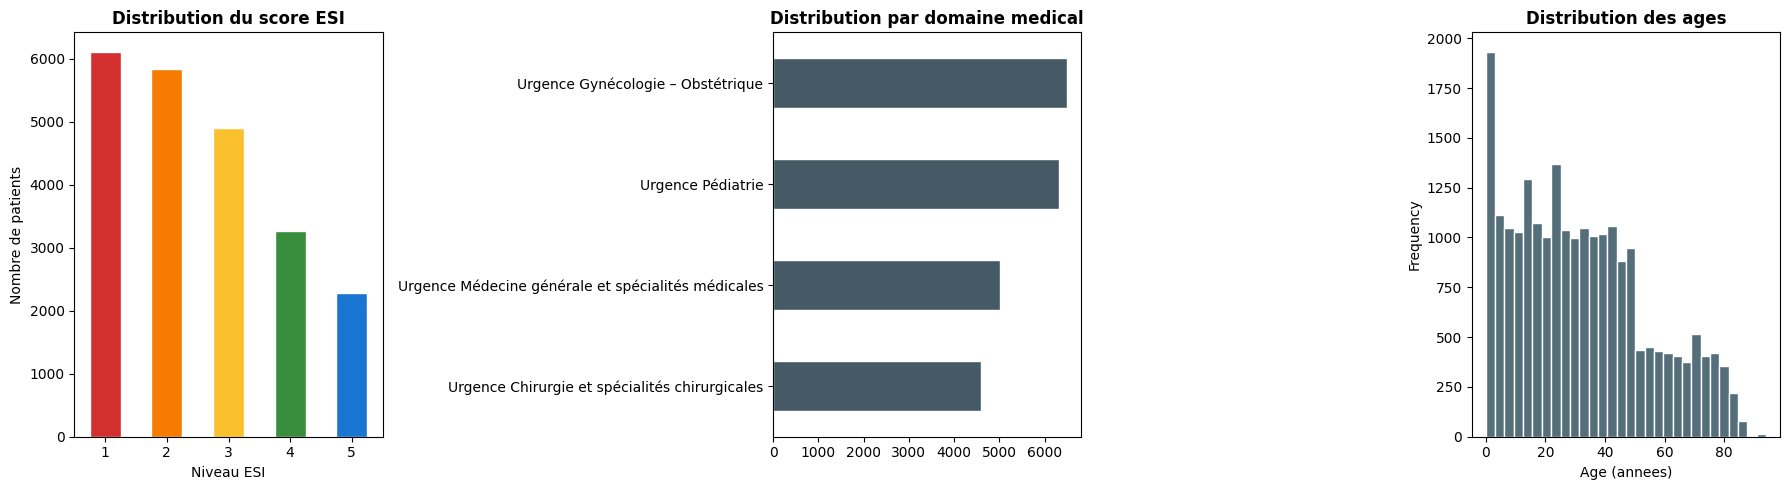

Domaines : 4 | ESI niveaux : 5
Age median : 29 ans | Sexe : {'Féminin': 14420, 'Masculin': 7972}


In [9]:
# Distribution des variables cibles et demographiques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution ESI
esi_colors = ['#D32F2F', '#F57C00', '#FBC02D', '#388E3C', '#1976D2']
df['ESI'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=esi_colors, edgecolor='white', rot=0
)
axes[0].set_title('Distribution du score ESI', fontweight='bold')
axes[0].set_xlabel('Niveau ESI')
axes[0].set_ylabel('Nombre de patients')

# Distribution Domaine
df['Domaine'].value_counts().plot(
    kind='barh', ax=axes[1], color='#455A64', edgecolor='white'
)
axes[1].set_title('Distribution par domaine medical', fontweight='bold')
axes[1].invert_yaxis()

# Distribution age
df['age'].dropna().plot(kind='hist', ax=axes[2], bins=30, color='#546E7A', edgecolor='white')
axes[2].set_title('Distribution des ages', fontweight='bold')
axes[2].set_xlabel('Age (annees)')

plt.tight_layout()
plt.show()

print(f"Domaines : {df['Domaine'].nunique()} | ESI niveaux : {df['ESI'].nunique()}")
print(f"Age median : {df['age'].median():.0f} ans | Sexe : {df['sexe'].value_counts().to_dict()}")

## 4. Extraction des constantes vitales

Les constantes vitales (temperature, frequence cardiaque, saturation, etc.) sont
encodees dans le texte libre du champ 'object'. On les extrait par expressions
regulieres pour en faire des features numeriques exploitables par les modeles.

Cette approche est justifiee car les constantes vitales sont les indicateurs
cliniques les plus determinants pour le triage.

In [10]:
import re

def _parse_number(patterns, text):
    """Extrait le premier nombre correspondant a l'un des patterns donnes."""
    if pd.isna(text):
        return None
    text = str(text)
    for pat in patterns:
        m = re.search(pat, text, re.I)
        if m:
            for g in m.groups():
                if g:
                    try:
                        return float(g.replace(',', '.'))
                    except ValueError:
                        continue
    return None


def _extract_bp(text):
    """Extrait la tension arterielle systolique et diastolique."""
    if pd.isna(text):
        return None, None
    text = str(text)
    for pat in [
        r'\bTA(?:[^\d]{1,10})?(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'\bTension(?: arterielle)?[^\d]{1,10}(\d{2,3})\s*[/x]\s*(\d{2,3})\b',
        r'(\d{2,3})\s*[/x]\s*(\d{2,3})\s*mmHg\b',
    ]:
        m = re.search(pat, text, re.I)
        if m:
            return float(m.group(1)), float(m.group(2))
    return None, None


def _extract_gcs(text):
    """Extrait le score de Glasgow (GCS)."""
    if pd.isna(text):
        return None
    text = str(text)
    for pat in [r'GCS.*?(\d{1,2})\s*/\s*15', r'Glasgow.*?(\d{1,2})\s*/\s*15']:
        m = re.search(pat, text, re.I)
        if m:
            return float(m.group(1))
    return None


def extraire_constantes(text):
    """
    Extrait l'ensemble des constantes vitales d'un texte d'examen clinique.

    Retourne un dictionnaire avec les cles :
    temp, fc, sat, fr, ta_sys, ta_dia, gcs
    """
    if pd.isna(text):
        return {k: None for k in ['temp', 'fc', 'sat', 'fr', 'ta_sys', 'ta_dia', 'gcs']}

    text = str(text)
    sbp, dbp = _extract_bp(text)

    return {
        # Pour la température corporelle
        'temp': _parse_number([
            r'(\d+(?:[.,]\d+)?)\s*°\s*[Cc]',
            r'[Tt](?:emp(?:erature)?)?°?(\d+(?:[.,]\d+)?)',
            r'T°(\d+(?:[.,]\d+)?)',
        ], text),
        # Pour la Fréquence cardiaque
        'fc': _parse_number([
            r'(\d+(?:[.,]\d+)?)\s*bpm',
            r'FC[^\d]*(\d+(?:[.,]\d+)?)',
            r'Pouls[^\d]*(\d+(?:[.,]\d+)?)',
        ], text),
        # Pour la saturation en oxygène
        'sat': _parse_number([
            r'SpO2[^\d]*(\d+(?:[.,]\d+)?)',
            r'(\d+(?:[.,]\d+)?)\s*%',
        ], text),
        # Pour la fréqunece repisratoire
        'fr': _parse_number([
            r'(\d+(?:[.,]\d+)?)\s*/\s*min',
            r'(\d+(?:[.,]\d+)?)\s*cpm',
            r'FR[^\d]*(\d+(?:[.,]\d+)?)',
        ], text),
        # Pour la tension artérielle systoliuqe et diastolique
        'ta_sys': sbp,
        'ta_dia': dbp,
        
        'gcs':   _extract_gcs(text),
    }


print("Fonctions d'extraction des constantes vitales definies.")

Fonctions d'extraction des constantes vitales definies.


In [11]:
# Application de l'extraction sur l'ensemble du dataset
vitals = df['object'].apply(extraire_constantes)
df = pd.concat([df, pd.DataFrame(vitals.tolist(), index=df.index)], axis=1)

# Valeurs normales de remplacement (imputation par valeur clinique de reference)
# Ces valeurs representent des constantes normales chez l'adulte
DEFAULTS = {
    'temp':   37.0,
    'fc':     80.0,
    'sat':    98.0,
    'fr':     18.0,
    'ta_sys': 120.0,
    'ta_dia':  80.0,
    'gcs':    15.0,
}
for col, val in DEFAULTS.items():
    df[col] = df[col].fillna(val)

# Indicateurs binaires de seuils cliniques critiques
# Ces flags encodent explicitement les seuils de gravite connus
df['alerte_hypoxie']     = (df['sat'] < 94).astype(int)
df['alerte_sat_critique']= (df['sat'] < 90).astype(int)
df['alerte_fievre']      = (df['temp'] >= 38.0).astype(int)
df['alerte_tachycardie'] = (df['fc'] > 100).astype(int)
df['alerte_bradycardie'] = (df['fc'] < 60).astype(int)
df['alerte_tachypnee']   = (df['fr'] > 20).astype(int)
df['alerte_bradypnee']   = (df['fr'] < 12).astype(int)
df['alerte_hta']         = ((df['ta_sys'] >= 140) | (df['ta_dia'] >= 90)).astype(int)
df['alerte_hypotension'] = ((df['ta_sys'] < 90) | (df['ta_dia'] < 60)).astype(int)

print("Constantes extraites et indicateurs d'alerte calcules.")
print(df[['temp', 'fc', 'sat', 'fr', 'ta_sys', 'ta_dia', 'gcs']].describe().loc[['mean', 'min', 'max']].round(1))

Constantes extraites et indicateurs d'alerte calcules.
      temp     fc    sat      fr  ta_sys  ta_dia   gcs
mean  37.3   94.3   93.4    20.0   119.4    77.1  14.8
min    2.0    1.0    0.9     0.0    60.0    30.0   3.0
max   92.0  500.0  100.0  3250.0   235.0   145.0  15.0


## 5. Preparation des features et encodage des cibles

On construit trois types de features complementaires :
- **Numeriques** : age, constantes vitales, indicateurs d'alerte, longueurs textuelles
- **Categorielles** : sexe, province (lieu)
- **Textuelles** : TF-IDF bigrammes sur le texte clinique combine (subject + object)

Le TF-IDF avec bigrammes permet de capturer des expressions medicales comme
"douleur abdominale" ou "detresse respiratoire" que l'unigramme decompose a tort.

Les deux cibles sont encodees separement :
- `Domaine` : 4 specialites medicales (classification en etape 1)
- `ESI` : niveaux 1 a 5 (classification en etape 2)

In [12]:
# Definition des groupes de features
FEATURES_NUM = [
    'age',
    'temp', 'fc', 'sat', 'fr', 'ta_sys', 'ta_dia', 'gcs',
    'alerte_hypoxie', 'alerte_sat_critique', 'alerte_fievre',
    'alerte_tachycardie', 'alerte_bradycardie',
    'alerte_tachypnee', 'alerte_bradypnee',
    'alerte_hta', 'alerte_hypotension',
    'len_texte', 'len_subject', 'len_object',
]
FEATURES_CAT  = ['sexe', 'lieu']
FEATURE_TEXT  = 'texte_clinique'

df_model = df.copy()

# Construction du texte clinique combine
df_model['texte_clinique'] = (
    df_model['subject'].fillna('') + ' ' + df_model['object'].fillna('')
).str.strip()

# Features de longueur : donnent une indication sur la richesse de l'anamnese
df_model['len_texte']   = df_model['texte_clinique'].str.len()
df_model['len_subject'] = df_model['subject'].fillna('').str.len()
df_model['len_object']  = df_model['object'].fillna('').str.len()

# Suppression des lignes avec cibles manquantes
df_clean = df_model.dropna(subset=['age', 'sexe', 'Domaine', 'ESI']).copy()

# Encodage des cibles
le_domaine = LabelEncoder()
le_esi     = LabelEncoder()

df_clean['domaine_enc'] = le_domaine.fit_transform(df_clean['Domaine'])
df_clean['esi_enc']     = le_esi.fit_transform(df_clean['ESI'])

print(f"Dataset apres nettoyage : {len(df_clean)} patients")
print(f"Domaines  ({len(le_domaine.classes_)}) : {le_domaine.classes_}")
print(f"ESI       ({len(le_esi.classes_)})     : {le_esi.classes_}")

Dataset apres nettoyage : 22392 patients
Domaines  (4) : ['Urgence Chirurgie et spécialités chirurgicales'
 'Urgence Gynécologie – Obstétrique'
 'Urgence Médecine générale et spécialités médicales' 'Urgence Pédiatrie']
ESI       (5)     : [1 2 3 4 5]


## 6. Construction des pipelines de transformation

Un `ColumnTransformer` sklearn centralise le preprocessing pour eviter la fuite
de donnees (data leakage) entre train et test. Chaque branche est independante :
- **Branche numerique** : imputation par la mediane + standardisation
- **Branche categorielle** : imputation par la valeur la plus frequente + encodage one-hot
- **Branche textuelle** : TF-IDF bigrammes (vocabulaire de 2000 termes, lissage log)

Ce design garantit que les parametres de transformation (moyenne, vocabulaire, etc.)
sont appris uniquement sur le jeu d'entrainement et appliques au jeu de test.

In [13]:
from sklearn.compose import ColumnTransformer

# Branche numerique
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Branche categorielle
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
])

# Branche textuelle (TF-IDF bigrammes)
# min_df=3 : terme present dans au moins 3 dossiers (evite le bruit)
# sublinear_tf=True : lissage logarithmique de la frequence
text_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=2000,
        min_df=3,
        ngram_range=(1, 2),
        sublinear_tf=True,
    )),
])

# Assemblage via ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num',  num_pipe,  FEATURES_NUM),
        ('cat',  cat_pipe,  FEATURES_CAT),
        ('text', text_pipe, FEATURE_TEXT),
    ],
    remainder='drop',
)

print("Preprocesseur ColumnTransformer configure :")
print(f"  Branche numerique  : {len(FEATURES_NUM)} features")
print(f"  Branche categorielle: {len(FEATURES_CAT)} features -> encodage OHE")
print(f"  Branche textuelle  : TF-IDF bigrammes, max 2000 termes")

Preprocesseur ColumnTransformer configure :
  Branche numerique  : 20 features
  Branche categorielle: 2 features -> encodage OHE
  Branche textuelle  : TF-IDF bigrammes, max 2000 termes


## 7. Preparation des jeux d'entrainement et de test

On effectue un split stratifie sur le Domaine (variable la plus structurante)
pour garantir que toutes les specialites sont representees proportionnellement
dans chaque partition. Le ratio 80/20 est standard pour des datasets de cette taille.

In [14]:
# Suppression des classes sous-representees (moins de 5 exemples)
for col in ['domaine_enc', 'esi_enc']:
    counts = df_clean[col].value_counts()
    valid  = counts[counts >= 5].index
    df_clean = df_clean[df_clean[col].isin(valid)]

X_raw  = df_clean[FEATURES_NUM + FEATURES_CAT + [FEATURE_TEXT]]
y_dom  = df_clean['domaine_enc'].values
y_esi  = df_clean['esi_enc'].values

# Split stratifie sur le domaine
idx = np.arange(len(df_clean))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, random_state=SEED, stratify=y_dom
)

X_train_raw, X_test_raw = X_raw.iloc[idx_train], X_raw.iloc[idx_test]

# Transformation des features (fit uniquement sur le train)
print("Construction des matrices de features...")
X_base_tr = preprocessor.fit_transform(X_train_raw)
X_base_te = preprocessor.transform(X_test_raw)

print(f"Train : {len(idx_train)} patients")
print(f"Test  : {len(idx_test)} patients")
print(f"Dimension de la matrice de features : {X_base_tr.shape[1]} colonnes")

Construction des matrices de features...
Train : 17913 patients
Test  : 4479 patients
Dimension de la matrice de features : 2053 colonnes


## 8. Fonctions d'entrainement et d'evaluation

La fonction `evaluer_modele` centralise l'entrainement et le calcul des trois
metriques retenues :
- **Accuracy** : proportion de predictions correctes
- **F1-macro** : moyenne non ponderee du F1 par classe (pertinent pour classes desequilibrees)
- **AUC-ROC macro** : capacite discriminante multi-classe (reference clinique dans Porto 2024)

Le DNN beneficie d'un early stopping sur la validation accuracy pour eviter le surapprentissage.

In [15]:
def evaluer_modele(nom, model, X_tr, y_tr, X_te, y_te, dense=False):
    """
    Entraine un modele et calcule Accuracy, F1-macro et AUC-ROC.

    Parametres
    ----------
    dense : bool
        True si le modele attend un tableau numpy dense (DNN).
        False pour les modeles sklearn acceptant les matrices sparse.

    Retourne
    --------
    Le modele entraine et un dict de metriques.
    """
    if dense:
        X_tr_in = X_tr.toarray().astype('float32')
        X_te_in = X_te.toarray().astype('float32')
    else:
        X_tr_in, X_te_in = X_tr, X_te

    model.fit(X_tr_in, y_tr)

    if dense:
        proba  = model.predict(X_te_in, verbose=0)
        y_pred = np.argmax(proba, axis=1)
    else:
        proba  = model.predict_proba(X_te_in)
        y_pred = model.predict(X_te_in)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro', zero_division=0)

    try:
        n_classes = len(np.unique(y_te))
        if n_classes == 2:
            auc = roc_auc_score(y_te, proba[:, 1])
        else:
            auc = roc_auc_score(
                y_te, proba,
                multi_class='ovr', average='macro'
            )
    except Exception:
        auc = float('nan')

    print(f"  {nom:<22s}  Accuracy={acc:.3f}  F1-macro={f1:.3f}  AUC={auc:.3f}")
    return model, {'nom': nom, 'acc': acc, 'f1': f1, 'auc': auc,
                   'model': model, 'proba': proba, 'dense': dense}


def construire_dnn(input_dim, n_classes, lr=1e-3):
    """
    Reseau de neurones dense a 3 couches cachees avec Batch Normalization.

    Architecture :
    Input -> [Dense(512) -> BN -> Dropout(0.4)]
          -> [Dense(256) -> BN -> Dropout(0.35)]
          -> [Dense(128) -> BN -> Dropout(0.30)]
          -> Softmax(n_classes)
    """
    inp = keras.Input(shape=(input_dim,))
    x   = inp
    for units, drop in [(512, 0.40), (256, 0.35), (128, 0.30)]:
        x = layers.Dense(units, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(drop)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def entrainer_dnn(X_tr, y_tr, X_te, y_te, n_classes, epochs=80):
    """
    Entraine le DNN avec early stopping et reduction du taux d'apprentissage.
    Retourne (modele, dict metriques) dans le meme format que evaluer_modele.
    """
    X_tr_d = X_tr.toarray().astype('float32')
    X_te_d = X_te.toarray().astype('float32')

    cb = [
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8, restore_best_weights=True
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5
        ),
    ]

    dnn = construire_dnn(X_tr_d.shape[1], n_classes)
    hist = dnn.fit(
        X_tr_d, y_tr,
        validation_split=0.15,
        epochs=epochs,
        batch_size=64,
        callbacks=cb,
        verbose=0,
    )

    proba  = dnn.predict(X_te_d, verbose=0)
    y_pred = np.argmax(proba, axis=1)

    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='macro', zero_division=0)
    try:
        auc = roc_auc_score(y_te, proba, multi_class='ovr', average='macro')
    except Exception:
        auc = float('nan')

    n_ep = len(hist.epoch)
    print(f"  {'DNN':<22s}  Accuracy={acc:.3f}  F1-macro={f1:.3f}  AUC={auc:.3f}  (epochs={n_ep})")
    return dnn, {'nom': 'DNN', 'acc': acc, 'f1': f1, 'auc': auc,
                 'model': dnn, 'proba': proba, 'dense': True}


print("Fonctions d'entrainement et d'evaluation definies.")

Fonctions d'entrainement et d'evaluation definies.


## 9. Etape 1  Prédiction

Les quatre algorithmes sont entrainés sur la même matrice de features.
Le meilleur modèle selon le F1-macro est selectionné pour generer les
probabilités qui enrichiront l'étape suivante.

**Pourquoi le F1-macro ?** Les classes (domaines) sont desequilibrees ;
l'accuracy seule surestimerait les performances sur les classes majoritaires.

In [16]:
print("=" * 60)
print("ETAPE 1 : DOMAINE MEDICAL")
print("=" * 60)

y_dom_tr = y_dom[idx_train]
y_dom_te = y_dom[idx_test]
n_dom    = len(le_domaine.classes_)

print(f"Classes : {le_domaine.classes_}")
print()

resultats_dom = []

# Regression Logistique
# Justification : modele de reference clinique (Porto 2024, AUC~0.83)
# class_weight='balanced' corrige le desequilibre des classes
_, r = evaluer_modele(
    'Regression Logistique',
    LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced', solver='lbfgs',
        multi_class='multinomial', random_state=SEED,
    ),
    X_base_tr, y_dom_tr, X_base_te, y_dom_te,
)
resultats_dom.append(r)

# Random Forest
# n_estimators=300 : bon equilibre variance/biais sans surcout majeur
_, r = evaluer_modele(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        min_samples_leaf=2, random_state=SEED, n_jobs=-1,
    ),
    X_base_tr, y_dom_tr, X_base_te, y_dom_te,
)
resultats_dom.append(r)

# XGBoost
# subsample et colsample_bytree : regularisation pour eviter le surapprentissage
_, r = evaluer_modele(
    'XGBoost',
    XGBClassifier(
        n_estimators=400, max_depth=7, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
    ),
    X_base_tr, y_dom_tr, X_base_te, y_dom_te,
)
resultats_dom.append(r)

# DNN
_, r = entrainer_dnn(X_base_tr, y_dom_tr, X_base_te, y_dom_te, n_dom)
resultats_dom.append(r)

# Selection du meilleur modele selon F1-macro
best_dom = max(resultats_dom, key=lambda x: x['f1'])
print(f"\nMeilleur modele DOMAINE : {best_dom['nom']}  (F1={best_dom['f1']:.3f})")

# Probabilites de domaine pour enrichir l'etape suivante
if best_dom['dense']:
    X_dense_tr = X_base_tr.toarray().astype('float32')
    proba_dom_tr = best_dom['model'].predict(X_dense_tr, verbose=0)
else:
    proba_dom_tr = best_dom['model'].predict_proba(X_base_tr)
proba_dom_te = best_dom['proba']

ETAPE 1 : DOMAINE MEDICAL
Classes : ['Urgence Chirurgie et spécialités chirurgicales'
 'Urgence Gynécologie – Obstétrique'
 'Urgence Médecine générale et spécialités médicales' 'Urgence Pédiatrie']

  Regression Logistique   Accuracy=0.978  F1-macro=0.977  AUC=0.999
  Random Forest           Accuracy=0.988  F1-macro=0.988  AUC=1.000
  XGBoost                 Accuracy=0.990  F1-macro=0.989  AUC=1.000
  DNN                     Accuracy=0.987  F1-macro=0.986  AUC=0.999  (epochs=34)

Meilleur modele DOMAINE : XGBoost  (F1=0.989)


## 10. Etape 2 Prediction du score ESI

La matrice de features est enrichie avec les probabilites predites par le meilleur
modele de l'etape 1. Cela permet aux modeles ESI d'exploiter l'information
hierarchique : savoir qu'un patient appartient a la chirurgie ou a la pediatrie
influence la distribution attendue des niveaux de gravite.

C'est le principe fondamental de la **prediction hierarchique** : chaque etape
apporte un contexte supplementaire a la suivante.

In [17]:
print("=" * 60)
print("ETAPE 2 : SCORE ESI")
print("=" * 60)

y_esi_tr = y_esi[idx_train]
y_esi_te = y_esi[idx_test]
n_esi    = len(le_esi.classes_)

print(f"Classes ESI : {le_esi.classes_}")
print()

# Enrichissement de la matrice avec les probabilites domaine
X_esi_tr = sp.hstack([X_base_tr, sp.csr_matrix(proba_dom_tr)]).tocsr()
X_esi_te = sp.hstack([X_base_te, sp.csr_matrix(proba_dom_te)]).tocsr()

resultats_esi = []

# Regression Logistique
_, r = evaluer_modele(
    'Regression Logistique',
    LogisticRegression(
        C=1.0, max_iter=1000,
        class_weight='balanced', solver='lbfgs',
        multi_class='multinomial', random_state=SEED,
    ),
    X_esi_tr, y_esi_tr, X_esi_te, y_esi_te,
)
resultats_esi.append(r)

# Random Forest
_, r = evaluer_modele(
    'Random Forest',
    RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        min_samples_leaf=2, random_state=SEED, n_jobs=-1,
    ),
    X_esi_tr, y_esi_tr, X_esi_te, y_esi_te,
)
resultats_esi.append(r)

# XGBoost
_, r = evaluer_modele(
    'XGBoost',
    XGBClassifier(
        n_estimators=400, max_depth=7, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=SEED, n_jobs=-1,
    ),
    X_esi_tr, y_esi_tr, X_esi_te, y_esi_te,
)
resultats_esi.append(r)

# DNN
_, r = entrainer_dnn(X_esi_tr, y_esi_tr, X_esi_te, y_esi_te, n_esi)
resultats_esi.append(r)

# Selection du meilleur modele
best_esi = max(resultats_esi, key=lambda x: x['f1'])
print(f"\nMeilleur modele ESI : {best_esi['nom']}  (F1={best_esi['f1']:.3f})")

ETAPE 2 : SCORE ESI
Classes ESI : [1 2 3 4 5]

  Regression Logistique   Accuracy=0.929  F1-macro=0.920  AUC=0.995
  Random Forest           Accuracy=0.931  F1-macro=0.921  AUC=0.995
  XGBoost                 Accuracy=0.932  F1-macro=0.924  AUC=0.996
  DNN                     Accuracy=0.929  F1-macro=0.924  AUC=0.995  (epochs=11)

Meilleur modele ESI : DNN  (F1=0.924)


## 11. Tableau de synthese et comparaison des performances

Ce tableau recapitule les trois metriques pour chacun des 8 modeles entraines
(4 algorithmes x 2 etapes). Il permet une comparaison directe et objective.

In [18]:
rows = []
for cible, resultats in [('Domaine', resultats_dom), ('ESI', resultats_esi)]:
    for r in resultats:
        rows.append({
            'Etape':    cible,
            'Algorithme': r['nom'],
            'Accuracy': round(r['acc'], 3),
            'F1-macro': round(r['f1'],  3),
            'AUC-ROC':  round(r['auc'], 3),
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

  Etape            Algorithme  Accuracy  F1-macro  AUC-ROC
Domaine Regression Logistique     0.978     0.977    0.999
Domaine         Random Forest     0.988     0.988    1.000
Domaine               XGBoost     0.990     0.989    1.000
Domaine                   DNN     0.987     0.986    0.999
    ESI Regression Logistique     0.929     0.920    0.995
    ESI         Random Forest     0.931     0.921    0.995
    ESI               XGBoost     0.932     0.924    0.996
    ESI                   DNN     0.929     0.924    0.995


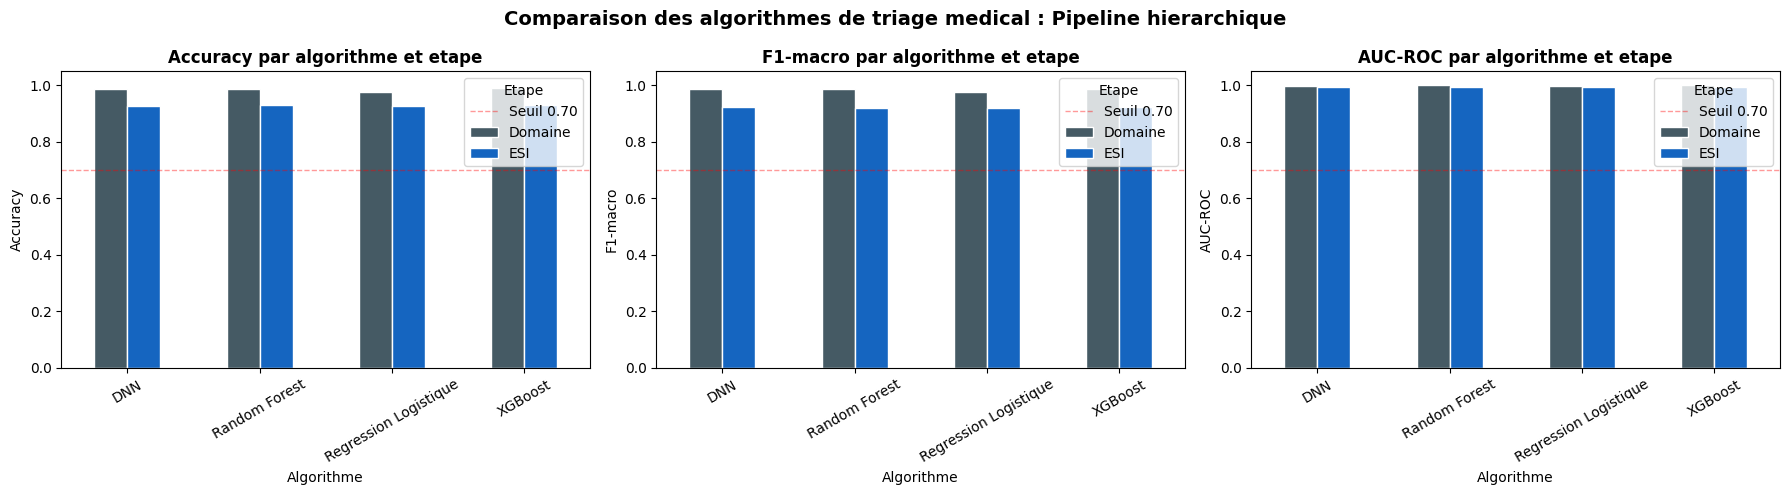

In [19]:
# Visualisation comparee des trois metriques
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics    = ['Accuracy', 'F1-macro', 'AUC-ROC']
colors_dom = ['#455A64', '#607D8B', '#78909C', '#90A4AE']
colors_esi = ['#1565C0', '#1976D2', '#1E88E5', '#42A5F5']

for ax, metric in zip(axes, metrics):
    pivot = df_results.pivot(index='Algorithme', columns='Etape', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', rot=30, color=[colors_dom[0], colors_esi[0]])
    ax.set_title(f'{metric} par algorithme et etape', fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.axhline(0.7, color='red', linestyle='--', alpha=0.4, linewidth=1, label='Seuil 0.70')
    ax.legend(title='Etape')

plt.suptitle(
    'Comparaison des algorithmes de triage medical : Pipeline hierarchique',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 12. Rapport detaille du meilleur modele ESI

Le rapport de classification par classe donne la precision, le rappel et le F1
pour chaque niveau ESI. La matrice de confusion permet de visualiser les erreurs
systematiques (ex. confusion entre ESI 3 et ESI 4, qui sont cliniquement proches).

Rapport detaille : Domaine | Meilleur algorithme : XGBoost
                                                    precision    recall  f1-score   support

    Urgence Chirurgie et spécialités chirurgicales       0.99      0.98      0.99       920
                 Urgence Gynécologie – Obstétrique       0.99      0.99      0.99      1297
Urgence Médecine générale et spécialités médicales       0.99      0.99      0.99      1001
                                 Urgence Pédiatrie       0.99      0.99      0.99      1261

                                          accuracy                           0.99      4479
                                         macro avg       0.99      0.99      0.99      4479
                                      weighted avg       0.99      0.99      0.99      4479



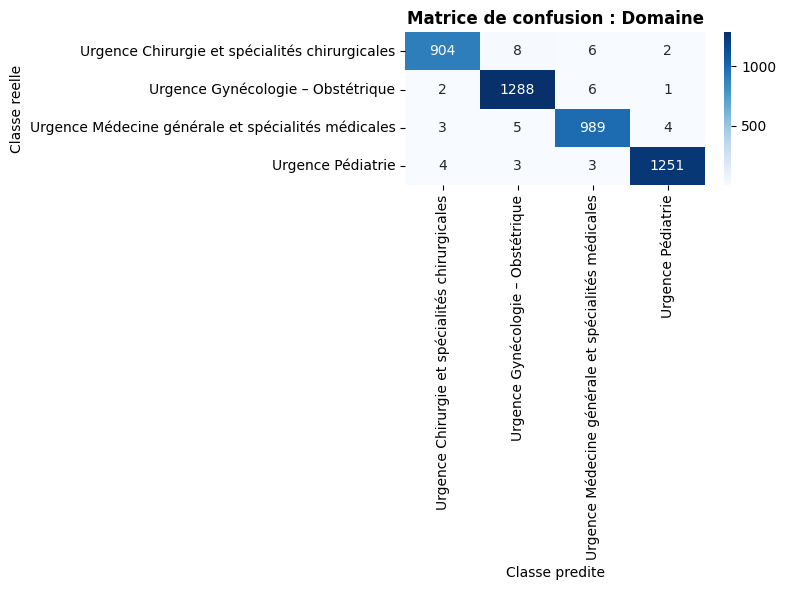

Rapport detaille : ESI | Meilleur algorithme : DNN
              precision    recall  f1-score   support

           1       0.97      0.97      0.97      1229
           2       0.96      0.92      0.94      1186
           3       0.82      0.97      0.89       972
           4       0.97      0.82      0.89       634
           5       0.96      0.90      0.93       458

    accuracy                           0.93      4479
   macro avg       0.94      0.92      0.92      4479
weighted avg       0.93      0.93      0.93      4479



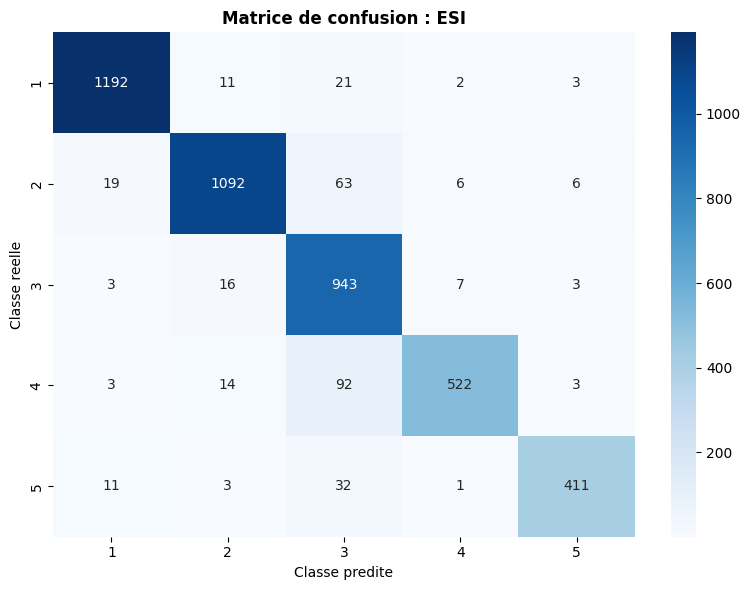

In [20]:
def rapport_detaille(nom_cible, best, X_te, y_te, le):
    """Affiche le rapport de classification et la matrice de confusion."""
    print("=" * 60)
    print(f"Rapport detaille : {nom_cible} | Meilleur algorithme : {best['nom']}")
    print("=" * 60)

    if best['dense']:
        y_pred = np.argmax(best['proba'], axis=1)
    else:
        y_pred = best['model'].predict(X_te)

    target_names = [str(c) for c in le.classes_]
    print(classification_report(y_te, y_pred, target_names=target_names, zero_division=0))

    if len(le.classes_) <= 10:
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax,
        )
        ax.set_title(f'Matrice de confusion : {nom_cible}', fontweight='bold')
        ax.set_ylabel('Classe reelle')
        ax.set_xlabel('Classe predite')
        plt.tight_layout()
        plt.show()


rapport_detaille('Domaine', best_dom, X_base_te, y_dom_te, le_domaine)
rapport_detaille('ESI',     best_esi, X_esi_te,  y_esi_te, le_esi)

## 13. Fonction de prediction pour un nouveau patient

Cette fonction reproduit le pipeline complet a l'inference. Elle prend en entree
les informations saisies au triage et retourne :
- Le domaine medical probable
- Le score ESI predit
- Le classement des 3 domaines les plus probables avec leur score de confiance

Note : la fonction appelle `extraire_constantes` sur le texte de l'examen clinique
pour reconstruire les features numeriques, exactement comme pendant l'entrainement.

In [21]:
def predire_patient(age, sexe, lieu, motif_consultation, examen_clinique, top_n=3):
    """
    Realise la prediction hierarchique pour un nouveau patient.

    Parametres
    ----------
    age                 : int ou float, age en annees
    sexe                : str, 'Feminin' ou 'Masculin'
    lieu                : str, province du Burkina Faso
    motif_consultation  : str, texte libre du motif (champ subject)
    examen_clinique     : str, texte libre de l'examen (champ object)
    top_n               : int, nombre de domaines a afficher dans le classement

    Retourne
    --------
    dict avec les cles : domaine, esi, top_domaines (DataFrame)
    """
    # Reconstruction du texte clinique
    texte = (str(motif_consultation) + ' ' + str(examen_clinique)).strip()

    # Extraction des constantes vitales depuis le texte d'examen
    cv = extraire_constantes(examen_clinique)

    # Construction du DataFrame patient avec toutes les features requises
    row = {
        'age':      age,
        'sexe':     sexe,
        'lieu':     lieu,
        FEATURE_TEXT: texte,
        # Constantes avec valeurs par defaut si non trouvees dans le texte
        'temp':   cv['temp']   or DEFAULTS['temp'],
        'fc':     cv['fc']     or DEFAULTS['fc'],
        'sat':    cv['sat']    or DEFAULTS['sat'],
        'fr':     cv['fr']     or DEFAULTS['fr'],
        'ta_sys': cv['ta_sys'] or DEFAULTS['ta_sys'],
        'ta_dia': cv['ta_dia'] or DEFAULTS['ta_dia'],
        'gcs':    cv['gcs']    or DEFAULTS['gcs'],
    }
    # Calcul des indicateurs d'alerte et des features de longueur
    row['alerte_hypoxie']     = int(row['sat'] < 94)
    row['alerte_sat_critique']= int(row['sat'] < 90)
    row['alerte_fievre']      = int(row['temp'] >= 38.0)
    row['alerte_tachycardie'] = int(row['fc'] > 100)
    row['alerte_bradycardie'] = int(row['fc'] < 60)
    row['alerte_tachypnee']   = int(row['fr'] > 20)
    row['alerte_bradypnee']   = int(row['fr'] < 12)
    row['alerte_hta']         = int(row['ta_sys'] >= 140 or row['ta_dia'] >= 90)
    row['alerte_hypotension'] = int(row['ta_sys'] < 90 or row['ta_dia'] < 60)
    row['len_texte']          = len(texte)
    row['len_subject']        = len(str(motif_consultation))
    row['len_object']         = len(str(examen_clinique))

    patient = pd.DataFrame([row])

    # Transformation des features (preprocesseur deja ajuste sur le train)
    X_p = preprocessor.transform(patient)

    # Etape 1 : domaine
    if best_dom['dense']:
        p_dom = best_dom['model'].predict(X_p.toarray().astype('float32'), verbose=0)
    else:
        p_dom = best_dom['model'].predict_proba(X_p)

    dom_pred = le_domaine.classes_[np.argmax(p_dom)]

    # Top-N domaines les plus probables
    top_idx = np.argsort(p_dom[0])[-top_n:][::-1]
    top_domaines = pd.DataFrame({
        'Rang': range(1, top_n + 1),
        'Domaine': le_domaine.classes_[top_idx],
        'Confiance (%)': (p_dom[0][top_idx] * 100).round(1),
    }).set_index('Rang')

    # Etape 2 : ESI (matrice enrichie par les probabilites domaine)
    X_esi = sp.hstack([X_p, sp.csr_matrix(p_dom)]).tocsr()
    if best_esi['dense']:
        p_esi = best_esi['model'].predict(X_esi.toarray().astype('float32'), verbose=0)
    else:
        p_esi = best_esi['model'].predict_proba(X_esi)

    esi_pred = le_esi.classes_[np.argmax(p_esi)]

    return {
        'domaine':     dom_pred,
        'esi':         esi_pred,
        'top_domaines': top_domaines,
    }


print("Fonction predire_patient() prete.")

Fonction predire_patient() prete.


In [22]:
# Exemple 1 : Femme enceinte, potentiellement grave
print("EXEMPLE 1 : Femme 28 ans, grossesse, douleurs abdominales")
res = predire_patient(
    age=28, sexe='Feminin', lieu='Kadiogo',
    motif_consultation='grossesse 30 SA, douleurs abdominales intenses, vomissements',
    examen_clinique='TA 120/80 mmHg, BDC foetaux presents, FC 95 bpm, SpO2 98%, T 37.2',
)
print(f"  Domaine predit : {res['domaine']}")
print(f"  ESI predit     : {res['esi']}")
print()
print(res['top_domaines'].to_string())

print()
print("-" * 60)

# Exemple 2 : Homme, douleurs thoraciques
print("\nEXEMPLE 2 : Homme 58 ans, douleurs thoraciques")
res2 = predire_patient(
    age=58, sexe='Masculin', lieu='Kadiogo',
    motif_consultation='douleurs thoraciques intenses irradiant dans le bras gauche, dyspnee',
    examen_clinique='TA 185/110 mmHg, FC 102 bpm, SpO2 91%, FR 26/min, GCS 14/15',
)
print(f"  Domaine predit : {res2['domaine']}")
print(f"  ESI predit     : {res2['esi']}")

print()
print("-" * 60)

# Exemple 3 : Enfant febrile
print("\nEXEMPLE 3 : Enfant 4 ans, fievre et toux")
res3 = predire_patient(
    age=4, sexe='Masculin', lieu='Houet',
    motif_consultation='fievre depuis 3 jours, toux, rhinorrhee',
    examen_clinique='etat general conserve, muqueuses humides, T 39.1, FC 110 bpm, SpO2 98%, FR 24/min',
)
print(f"  Domaine predit : {res3['domaine']}")
print(f"  ESI predit     : {res3['esi']}")

EXEMPLE 1 : Femme 28 ans, grossesse, douleurs abdominales
  Domaine predit : Urgence Chirurgie et spécialités chirurgicales
  ESI predit     : 5

                                                 Domaine  Confiance (%)
Rang                                                                   
1         Urgence Chirurgie et spécialités chirurgicales      80.900002
2     Urgence Médecine générale et spécialités médicales      15.100000
3                      Urgence Gynécologie – Obstétrique       2.600000

------------------------------------------------------------

EXEMPLE 2 : Homme 58 ans, douleurs thoraciques
  Domaine predit : Urgence Chirurgie et spécialités chirurgicales
  ESI predit     : 1

------------------------------------------------------------

EXEMPLE 3 : Enfant 4 ans, fievre et toux
  Domaine predit : Urgence Pédiatrie
  ESI predit     : 2


## 14. Sauvegarde du pipeline

On sauvegarde l'integralite des artefacts necessaires au deploiement en production :
le preprocesseur, les encodeurs de labels, et les deux meilleurs modeles.

Les modeles DNN sont sauvegardes au format Keras natif (.keras) ;
les modeles sklearn sont sauvegardes via joblib (serialisation efficace pour numpy).

In [23]:
os.makedirs('modeles', exist_ok=True)

# Sauvegarde du preprocesseur et des encodeurs
joblib.dump(preprocessor,  'modeles/preprocesseur.pkl')
joblib.dump(le_domaine,    'modeles/label_encoder_domaine.pkl')
joblib.dump(le_esi,        'modeles/label_encoder_esi.pkl')

# Sauvegarde des meilleurs modeles
def sauvegarder(nom_fichier, modele):
    chemin = os.path.join('modeles', nom_fichier)
    if hasattr(modele, 'save'):
        modele.save(chemin)
    else:
        joblib.dump(modele, chemin)
    print(f"  {nom_fichier}")

print("Artefacts sauvegardes dans modeles/ :")

if best_dom['dense']:
    sauvegarder('best_domaine.keras', best_dom['model'])
else:
    sauvegarder('best_domaine.pkl',   best_dom['model'])

if best_esi['dense']:
    sauvegarder('best_esi.keras', best_esi['model'])
else:
    sauvegarder('best_esi.pkl',   best_esi['model'])

# Configuration generale pour le rechargement
config = {
    'FEATURES_NUM':   FEATURES_NUM,
    'FEATURES_CAT':   FEATURES_CAT,
    'FEATURE_TEXT':   FEATURE_TEXT,
    'DEFAULTS':       DEFAULTS,
    'best_dom_nom':   best_dom['nom'],
    'best_esi_nom':   best_esi['nom'],
    'best_dom_dense': best_dom['dense'],
    'best_esi_dense': best_esi['dense'],
}
joblib.dump(config, 'modeles/config.pkl')
sauvegarder('config.pkl', config)

print("\nSauvegarde terminee. Les modeles sont prets pour le deploiement.")

Artefacts sauvegardes dans modeles/ :
  best_domaine.pkl
  best_esi.keras
  config.pkl

Sauvegarde terminee. Les modeles sont prets pour le deploiement.


## 15. Pistes d'amelioration

Ce notebook constitue une base solide. Les ameliorations suivantes sont recommandees
pour une version de production :

**Equilibrage des classes**
- Appliquer SMOTE ou ADASYN sur les niveaux ESI sous-represented (ex. ESI 1 et 5)
- Ou augmenter le poids de ces classes via `class_weight` deja actif sur LR et RF

**Optimisation des hyperparametres**
- Utiliser Optuna ou GridSearchCV pour XGBoost (learning_rate, max_depth, n_estimators)
- Tester differentes tailles de vocabulaire TF-IDF (500, 1000, 2000, 5000)

**Encodage textuel avance**
- Remplacer TF-IDF par CamemBERT (modele BERT en francais) pour mieux capturer
  le contexte medical : "pas de douleur" vs "douleur" seraient distingues correctement

**Calibration des probabilites**
- Appliquer `CalibratedClassifierCV` pour que les scores de confiance soient
  interpretables comme des probabilites reelles (utile pour l'aide a la decision)

**Deploiement**
- Exposer la fonction `predire_patient` via une API FastAPI
- Integrer un module d'explication (SHAP ou LIME) pour la tracabilite clinique
